# BrandSuit AI — YouTube category + brand match

The MVP is **not** “unsafe yes/no”. On trending, YouTube already filtered violence.
The question is: **given title + description, what is the category?** Then the brand applies its own list (Nike / bank / cereal).

Track:

**Part 1 (now)**
1. Load the CSV + the category JSON
2. Inspect columns, grain, repeated `video_id`
3. Features vs label; classification
4. One row per video (`TODO`)
5. Map `category_id` → 5 MVP classes (`TODO`)
6. Look at the distribution (the chart has a purpose)
7. Dummy baseline (always the most common class)

**Part 2 (later)**
- not yet (train/test, model, macro-F1)

> Run in order. Kernel: **Python 3.13**. `TODO (STUDENT)` is your turn. Mini-checks: answer in your own words.


## 1) Load the data

Each CSV row is **a video on one trending day** (not yet “one unique video”).

Question to keep in your head:

> Looking only at title + description, can I guess the category YouTube gave?

`category_id` is the **answer key** (`y`). It does not go into `X` — that would be cheating.


In [45]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# KEEP: notebooks/ is one level below the project folder
RAW = Path("../data/raw")
csv_path = RAW / "USvideos.csv"
json_path = RAW / "US_category_id.json"
print("csv:", csv_path.resolve())
print("exists:", csv_path.exists())

df = pd.read_csv(csv_path)
df.head(3)


csv: C:\Users\natha\OneDrive\Documentos\data science\Python Projects\bar-ilan-classes\Brandsafe-ai\data\raw\USvideos.csv
exists: True


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...


## 2) Inspect

Compare `shape[0]` (rows) with `video_id.nunique()` (real videos).


In [46]:
print("shape:", df.shape)
print("\ncolumns:", list(df.columns))
print("\ndtypes:\n", df.dtypes)
print("\nrows:", len(df))
print("unique video_id:", df["video_id"].nunique())
print("\nnull descriptions:", df["description"].isna().sum())

# KEEP: size() = COUNT(*) by category_id; False (capital F) is not false
category_id_qty = (
    df.groupby("category_id").size().reset_index(name="qty")
)
print("\n qty by category id:")
print(category_id_qty.sort_values("qty", ascending=False))


shape: (40949, 16)

columns: ['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description']

dtypes:
 video_id                    str
trending_date               str
title                       str
channel_title               str
category_id               int64
publish_time                str
tags                        str
views                     int64
likes                     int64
dislikes                  int64
comment_count             int64
thumbnail_link              str
comments_disabled          bool
ratings_disabled           bool
video_error_or_removed     bool
description                 str
dtype: object

rows: 40949
unique video_id: 6351

null descriptions: 570

 qty by category id:
    category_id   qty
9            24  9964
2            10  6472
11           26  4146
8            23  3457
7 

The JSON turns the number `category_id` into a name (Sports, Music, …).

**Term:** `category_id`  
**In this project:** it is the raw `y`. Then we map it to 5 classes.  
**In an interview:** “I used the official category as the label. I did not put it in the features.”


In [47]:
# KEEP: YouTube API JSON is nested: items → snippet → title
with json_path.open(encoding="utf-8") as f:
    payload = json.load(f)

id_to_name = {}
for item in payload["items"]:
    cat_id = int(item["id"])
    name = item["snippet"]["title"]
    id_to_name[cat_id] = name

print("how many categories in the JSON:", len(id_to_name))
for cat_id, name in sorted(id_to_name.items()):
    print(f"{cat_id:3d}  {name}")


how many categories in the JSON: 32
  1  Film & Animation
  2  Autos & Vehicles
 10  Music
 15  Pets & Animals
 17  Sports
 18  Short Movies
 19  Travel & Events
 20  Gaming
 21  Videoblogging
 22  People & Blogs
 23  Comedy
 24  Entertainment
 25  News & Politics
 26  Howto & Style
 27  Education
 28  Science & Technology
 29  Nonprofits & Activism
 30  Movies
 31  Anime/Animation
 32  Action/Adventure
 33  Classics
 34  Comedy
 35  Documentary
 36  Drama
 37  Family
 38  Foreign
 39  Horror
 40  Sci-Fi/Fantasy
 41  Thriller
 42  Shorts
 43  Shows
 44  Trailers


### Mini-check (write in your own words)

- **Features (`X`)** = ...
- **Target / label (`y`)** = ...
- Is this **regression** or **classification**? Why?
- Why must `category_id` **not** go into `X`?
- Why are there more **rows** than **unique videos**?


## 3) Your turn: one row per video

The model grain is **one video**, not one day on the ranking.
If the same `video_id` sits in train and test, the test cheats.

Copies share the same category. You **do not** relabel. You **drop duplicates**.


In [48]:
# TODO (STUDENT): keep one row per video_id
# HINT: DataFrame.drop_duplicates(subset=..., keep="first")
# The line below is STILL wrong on purpose (copies everything). Change it.
df_one = df.drop_duplicates(subset="video_id")

print("original rows :", len(df))
print("after your drop:", len(df_one))
print("unique video_id  :", df_one["video_id"].nunique())
# If the drop is right, the last two lines match (~6351).


original rows : 40949
after your drop: 6351
unique video_id  : 6351


## 4) Your turn: 5 MVP classes

Decision (D2): Sports, News/Politics, Gaming, Entertainment, Other.

| YouTube (name in the JSON) | Our `y` |
|---|---|
| Sports | Sports |
| News & Politics | News / Politics |
| Gaming | Gaming |
| Entertainment, Comedy, Music, Film & Animation | Entertainment |
| everything else | Other |

Fill in the dictionary. The first three are done; Entertainment is missing.


In [49]:
# TODO (STUDENT): complete Entertainment (ids you saw in the JSON print)
# HINT: look up Music, Comedy, Film & Animation, Entertainment in the list
category_mapping = {
    "Autos & Vehicles": "Lifestyle & Interests",
    "Comedy": "Entertainment & Culture",
    "Education": "Education, Science & Technology",
    "Entertainment": "Entertainment & Culture",
    "Film & Animation": "Entertainment & Culture",
    "Gaming": "Gaming",
    "Howto & Style": "Lifestyle & Interests",
    "Music": "Entertainment & Culture",
    "News & Politics": "News, Politics & Society",
    "Nonprofits & Activism": "News, Politics & Society",
    "People & Blogs": "Lifestyle & Interests",
    "Pets & Animals": "Lifestyle & Interests",
    "Science & Technology": "Education, Science & Technology",
    "Shows": "Entertainment & Culture",
    "Sports": "Sports",
    "Travel & Events": "Lifestyle & Interests"
}



df_one = df_one.copy()
# KEEP: the name comes from the JSON; y comes from your mapping. All on df_one (unique videos).
df_one["youtube_name"] = df_one["category_id"].map(id_to_name)
df_one["y"] = df_one["youtube_name"].map(category_mapping).fillna("Other")

df_grouped_category = df_one["y"].value_counts().reset_index(name="qty")
df_perc = df_grouped_category.assign(
    perc=round(df_grouped_category["qty"] / len(df_one), 2)
)

print(df_perc.sort_values("perc", ascending=False))
print("\ncheck (youtube_name vs y):")
print(pd.crosstab(df_one["youtube_name"], df_one["y"]))
print()


                                 y   qty  perc
0          Entertainment & Culture  3287  0.52
1            Lifestyle & Interests  1361  0.21
2  Education, Science & Technology   630  0.10
3         News, Politics & Society   519  0.08
4                           Sports   451  0.07
5                           Gaming   103  0.02

check (youtube_name vs y):
y                      Education, Science & Technology  \
youtube_name                                             
Autos & Vehicles                                     0   
Comedy                                               0   
Education                                          250   
Entertainment                                        0   
Film & Animation                                     0   
Gaming                                               0   
Howto & Style                                        0   
Music                                                0   
News & Politics                                      0   
Nonpr

## 5) Visualize the question

Chart question: **are the 5 classes balanced, or is one of them huge?**
That tells you whether the guess “always the big class” already gets a high score.


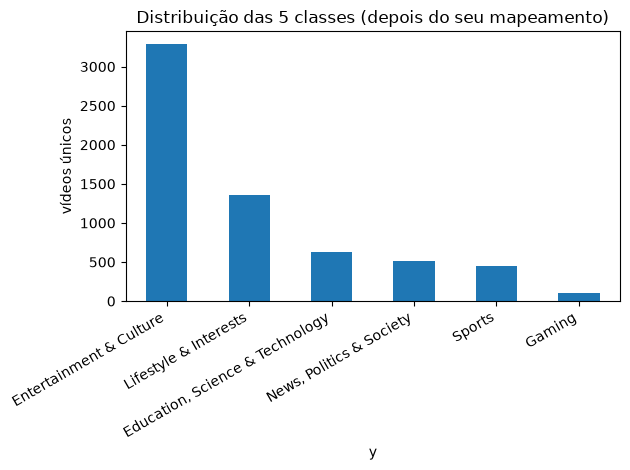

y
Entertainment & Culture            3287
Lifestyle & Interests              1361
Education, Science & Technology     630
News, Politics & Society            519
Sports                              451
Gaming                              103
Name: count, dtype: int64


In [50]:
counts = df_one["y"].value_counts()
ax = counts.plot(kind="bar")
ax.set_ylabel("unique videos")
ax.set_title("Distribution of the 5 classes (after your mapping)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
print(counts)


Look at the chart and answer:

1. Which class has the most videos?
2. If the dummy **always** guesses that class, is accuracy high or low? Why?
3. Is Music still in Other? (if yes, the Entertainment mapping is not finished)


## 6) Dummy baseline

This is **not** a model yet. It is the floor: always the most common class.
The Part 2 model needs to **beat** this number — otherwise it learned nothing useful.


In [51]:
# Baseline = dummy guess: always the most common class
most_common = df_one["y"].mode()[0]
baseline_acc = (df_one["y"] == most_common).mean()
print("most common class:", most_common)
print("baseline accuracy:", round(baseline_acc, 3))
print("n videos:", len(df_one))


most common class: Entertainment & Culture
baseline accuracy: 0.518
n videos: 6351


## 7) Optional: build `X` and `y` (no training yet)

Description is sometimes empty. We join title + description into one string.


In [52]:
# KEEP: fillna because NaN + string becomes NaN again
df_one["text"] = (
    df_one["title"].fillna("") + " " + df_one["description"].fillna("")
).str.strip()

X = df_one["text"]
y = df_one["y"]
print("X len:", len(X), "y len:", len(y))
print("example X:\n", X.iloc[0][:300])


X len: 6351 y len: 6351
exemplo X:
 WE WANT TO TALK ABOUT OUR MARRIAGE SHANTELL'S CHANNEL - https://www.youtube.com/shantellmartin\nCANDICE - https://www.lovebilly.com\n\nfilmed this video in 4k on this -- http://amzn.to/2sTDnRZ\nwith this lens -- http://amzn.to/2rUJOmD\nbig drone - http://tinyurl.com/h4ft3oy\nOTHER GEAR ---  http://a


### Checkpoint

Send in the chat, in your own words:

1. How many rows after the `drop`? Does that match unique `video_id`?
2. Did Music/Comedy go to Entertainment, or stay in Other?
3. What was the baseline accuracy, and why is that **not** enough for a kids cereal brand?

Do not move to Part 2 yet.


## 8) Part 2 — train, test, and the dummy on *test*

Run the Part 1 cells first (`df_one` with a `y` column).

**Story**
- `train` = study cards (the model may see the answer key)
- `test` = hidden exam (we only see the grade at the end)
- `stratify=y` = the exam has the **same class mix** as the notebook (otherwise the exam can be all Entertainment)

The 0.52 baseline was on the **full** dataset. In Part 2 we compare with the dummy **only on test** — otherwise it is cheating.


### Part 2 map (this is not train vs precision)

Precision and recall are born **together**, only on test. What changes is the pile.

```text
6351 videos (df_one)
├── 80% TRAIN  →  notebook (may see the answer key)
│     ├── TfidfVectorizer.fit_transform(X_train)   →  notebook words
│     └── LogisticRegression.fit(..., y_train)    →  the student studies
│
└── 20% TEST   →  exam (answer key hidden until the end)
      ├── vec.transform(X_test)                   →  same columns, no cheating
      ├── model.predict(...) → y_pred            →  student guess
      └── compare y_pred with y_test
            ├── accuracy     →  hits / all 1271
            ├── recall News  →  News hits / 104 that WERE News
            └── precision News →  News hits / ~83 that IT CALLED News
```

```mermaid
flowchart TD
  A["df_one ~6351 videos"] --> B[train_test_split]
  B --> TR["TRAIN 80%\nX_train + y_train"]
  B --> TE["TEST 20%\nX_test + y_test"]
  TR --> V["TF-IDF fit_transform"]
  V --> F["model.fit study"]
  TE --> T["TF-IDF transform"]
  F --> P["model.predict"]
  T --> P
  P --> YP["y_pred guesses"]
  TE --> YT["y_test answer key"]
  YP --> C[compare on TEST]
  YT --> C
  C --> ACC["accuracy\nall videos"]
  C --> REC["recall News\ndenominator = were News"]
  C --> PRE["precision News\ndenominator = called News"]
```


In [53]:
# KEEP: fillna because NaN + text becomes NaN
text = (df_one["title"].fillna("") + " " + df_one["description"].fillna("")).str.strip()
X = text
y = df_one["y"]

from sklearn.model_selection import train_test_split

# 80% study, 20% exam. random_state=42 = the same exam if you run it again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("train:", X_train.shape, "test:", X_test.shape)
print("train (share):")
print(y_train.value_counts(normalize=True).round(3))
print("test (share):")
print(y_test.value_counts(normalize=True).round(3))

# Honest dummy: always guess the most common TRAIN class; score on TEST
most_common = y_train.mode()[0]
baseline_acc_test = (y_test == most_common).mean()
print("\ndummy (always", most_common, ") on test:", round(baseline_acc_test, 3))


train: (5080,) test: (1271,)
train (share):
y
Entertainment & Culture            0.518
Lifestyle & Interests              0.214
Education, Science & Technology    0.099
News, Politics & Society           0.082
Sports                             0.071
Gaming                             0.016
Name: proportion, dtype: float64
test (share):
y
Entertainment & Culture            0.518
Lifestyle & Interests              0.214
Education, Science & Technology    0.099
News, Politics & Society           0.082
Sports                             0.071
Gaming                             0.017
Name: proportion, dtype: float64

dummy (always Entertainment & Culture ) on test: 0.518


## 9) Text → numbers, then the student

Logistic Regression does not read sentences. First we turn the text into a **table of numbers**.

**Term:** *TF-IDF*  
**In this project:** each word (or word pair) becomes a column; the number is “this shows up in this video and not in every video”.  
**In an interview:** “It is a classic way to vectorize text before a linear model. Fit the vectorizer on train only so the exam vocabulary does not leak.”

Then:

| Code | Story |
|---|---|
| `.fit(X_train, y_train)` | the student studies |
| `.predict(X_test)` | the exam, no answer key |
| `y_pred` | the student's answers |
| `y_test` | the answer key |
| `accuracy_score` | % correct |


In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# KEEP: fit TF-IDF on train only. transform on test uses the same vocabulary.
vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 1), min_df=2)
X_train_vec = vec.fit_transform(X_train)  # learns which words exist in the notebook
X_test_vec = vec.transform(X_test)        # exam: do not create a new column from the answer key

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)           # study
y_pred = model.predict(X_test_vec)        # exam

model_acc = accuracy_score(y_test, y_pred)
model_f1 = f1_score(y_test, y_pred, average="macro")

print("model accuracy :", round(model_acc, 3))
print("dummy accuracy :", round(baseline_acc_test, 3))
print("model macro-F1 :", round(model_f1, 3))


model accuracy : 0.796
dummy accuracy : 0.518
model macro-F1 : 0.673


## 10) Where it fails (confusion matrix)

Accuracy is one number. The matrix shows **which class was confused with which**.

For the cereal brand: the dangerous cell is true **News, Politics & Society** predicted as **Entertainment & Culture** (the policy would say YES).

**Term:** *macro-F1*  
**In this project:** F1 of each class, then the unweighted mean. Entertainment does not hide News.  
**In an interview:** “I did not optimize accuracy alone. With a large class, I look at macro-F1 and the News row.”


                                 precision    recall  f1-score   support

Education, Science & Technology       0.84      0.52      0.64       126
        Entertainment & Culture       0.77      0.94      0.85       658
                         Gaming       1.00      0.14      0.25        21
          Lifestyle & Interests       0.79      0.71      0.75       272
       News, Politics & Society       0.89      0.71      0.79       104
                         Sports       0.95      0.63      0.76        90

                       accuracy                           0.80      1271
                      macro avg       0.87      0.61      0.67      1271
                   weighted avg       0.81      0.80      0.79      1271



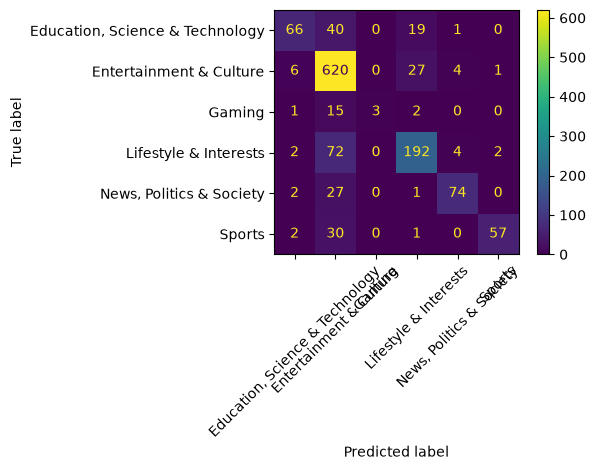

In [55]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45)
plt.tight_layout()
plt.show()


Look at the report and the matrix:

1. Was model accuracy **higher**, **lower**, or **equal** to the dummy on test?
2. Which class has the lowest recall?
3. A kids brand is hurt if News is predicted as Entertainment. Is that cell **dark** (many errors) or **light**?

### TODO (STUDENT)

In the cell below, rerun the same model with `class_weight="balanced"` (the student pays more attention to rare classes). Compare macro-F1 and News recall.
Do not delete the model from cell 9; copy it and change **only** that option.


In [56]:
# TODO (STUDENT): same TF-IDF, same split, LogisticRegression with class_weight="balanced"
# HINT: class_weight="balanced" goes into LogisticRegression(...)
# The line below is STILL the unweighted model. Change it.

model_b = LogisticRegression(max_iter=1000, class_weight = 'balanced')  # weight was missing
model_b.fit(X_train_vec, y_train)
y_pred_b = model_b.predict(X_test_vec)

print("macro-F1 unweighted :", round(f1_score(y_test, y_pred, average="macro"), 3))
print("macro-F1 with weight?:", round(f1_score(y_test, y_pred_b, average="macro"), 3))
print("\nreport (your version):")
print(classification_report(y_test, y_pred_b, zero_division=0))


macro-F1 unweighted : 0.673
macro-F1 with weight?: 0.718

report (your version):
                                 precision    recall  f1-score   support

Education, Science & Technology       0.68      0.71      0.70       126
        Entertainment & Culture       0.89      0.81      0.85       658
                         Gaming       0.43      0.48      0.45        21
          Lifestyle & Interests       0.69      0.77      0.73       272
       News, Politics & Society       0.68      0.89      0.77       104
                         Sports       0.87      0.76      0.81        90

                       accuracy                           0.79      1271
                      macro avg       0.71      0.74      0.72      1271
                   weighted avg       0.80      0.79      0.79      1271



### Checkpoint — Part 2

Send in the chat:

1. Model accuracy vs dummy on **test** (two numbers).
2. Did `class_weight="balanced"` help News recall? Yes/no + a number.
3. In one interview sentence: why must TF-IDF `fit` not use `X_test`?

Do not move to the Streamlit demo yet.


## 11) Error analysis — kids-brand false yes

Run the **balanced** `class_weight` model cell first (`y_pred_b`).

We are not looking at accuracy again. We look at **real videos** where:

- true label = News, Politics & Society
- guess = Entertainment & Culture

The cereal policy **accepts** Entertainment, so these errors become **YES** in the paper.

Hypothesis (you confirm by reading the titles): the text mixes celebrity/comedy **and** politics, or YouTube labeled News on something that looks like a talk show.


In [ ]:
# KEEP: y_test is a Series; y_pred_b is an array. Align by value, no JOIN.
NEWS = "News, Politics & Society"
ENT = "Entertainment & Culture"

err = pd.DataFrame({
    "title": df_one.loc[X_test.index, "title"].values,
    "text": X_test.to_numpy(),
    "y_true": y_test.to_numpy(),
    "y_pred": y_pred_b,
})

news_row = err[err["y_true"] == NEWS]
print("News in the test set:", len(news_row))
print("guesses when it was News:")
print(news_row["y_pred"].value_counts())

cereal_false_yes = err[(err["y_true"] == NEWS) & (err["y_pred"] == ENT)]
print("\nkids false yes (News -> Entertainment):", len(cereal_false_yes))
cereal_false_yes[["title", "y_true", "y_pred"]].head(15)


Look at the titles in the table and answer:

1. How many test-set News videos went to Entertainment? (the print above)
2. Does any title **look like** real news (election, senate, Trump)?
3. Does any look more like Late Night / a comedian talking politics? (then the error may be YouTube's **label**, not only the model)

### TODO (STUDENT)

In the cell below, paste **two** titles: one you think is a model error, one you think is a dubious label.


In [ ]:
# TODO (STUDENT): replace the ... with your own words
print("Example A (model error): ...")
print("  because the text talks about ... and the guess was still Entertainment")
print()
print("Example B (dubious label): ...")
print("  because ...")


### Checkpoint — error analysis

Send in the chat:

1. How many false yes (News → Entertainment) on the exam?
2. Your hypothesis in one sentence: does the model fail more from **show wording** or from a **bad label**?
3. What would the next experiment be (no neural net): more n-grams, more News weight, or hand-relabel 20 videos?

Do not build Streamlit yet.


## 12) Experiment — n-grams `(1, 2)`

You chose this because the hypothesis was **show wording**: the model sees `star` / `Coach` and misses the news phrase.

- `(1, 1)` = single words only (`submarine`, `star`)
- `(1, 2)` = word **and** pair (`missing Argentine`, `dead at`)

Same split, same `y`, same `class_weight="balanced"`.
**New** `TfidfVectorizer`: `fit` only on `X_train` (the exam rule did not change).

Product metric in this test: the **4** false yes (News → Entertainment). If that does not drop, n-grams did not fix the kids brand.


In [60]:
# TODO (STUDENT): ngram_range=(1, 2). Rest unchanged: fit on train only, balanced.
# HINT: (1, 1) = word; (1, 2) = word + pair
# The line below is STILL unigram. Change it.

vec_ng = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)  # pair was missing
X_train_ng = vec_ng.fit_transform(X_train)
X_test_ng = vec_ng.transform(X_test)

model_ng = LogisticRegression(max_iter=1000, class_weight="balanced")
model_ng.fit(X_train_ng, y_train)
y_pred_ng = model_ng.predict(X_test_ng)

print("macro-F1 unigram :", round(f1_score(y_test, y_pred_b, average="macro"), 3))
print("macro-F1 n-grams?:", round(f1_score(y_test, y_pred_ng, average="macro"), 3))
print("\nn-grams report:")
print(classification_report(y_test, y_pred_ng, zero_division=0))

NEWS = "News, Politics & Society"
ENT = "Entertainment & Culture"
n_false_uni = ((y_test.to_numpy() == NEWS) & (y_pred_b == ENT)).sum()
n_false_ng = ((y_test.to_numpy() == NEWS) & (y_pred_ng == ENT)).sum()
print("\nkids false yes (News -> Entertainment)")
print("  unigram :", n_false_uni)
print("  n-grams :", n_false_ng)


macro-F1 unigram : 0.718
macro-F1 n-grams?: 0.716

n-grams report:
                                 precision    recall  f1-score   support

Education, Science & Technology       0.62      0.71      0.66       126
        Entertainment & Culture       0.91      0.79      0.85       658
                         Gaming       0.45      0.62      0.52        21
          Lifestyle & Interests       0.68      0.76      0.72       272
       News, Politics & Society       0.65      0.89      0.75       104
                         Sports       0.87      0.73      0.80        90

                       accuracy                           0.78      1271
                      macro avg       0.70      0.75      0.72      1271
                   weighted avg       0.80      0.78      0.79      1271


false yes cereal (News -> Entertainment)
  unigram : 4
  n-grams : 2


### Checkpoint — n-grams

Send in the chat:

1. Did you switch to `(1, 2)`? (if both macro-F1 values come out equal, it is still `(1, 1)`)
2. Macro-F1: unigram vs n-grams (two numbers).
3. Kids false yes: 4 → ?
4. In one sentence: did n-grams fix the kids brand or not?

Still no Streamlit.


## 13) The 2 that still break the paper

n-grams cut 4 → 2. Macro-F1 stayed the same. For the cereal brand, **2 is still a failure**.

Before another `.fit`, look at **who** those 2 are. The question changes:

- if it is still the **submarine** → the model did not learn news
- if it is **Jerry / Rose / Pepsi** → n-grams already caught what it could; the rest is label or policy


In [ ]:
# KEEP: same exam, now with y_pred_ng
NEWS = "News, Politics & Society"
ENT = "Entertainment & Culture"

still = pd.DataFrame({
    "title": df_one.loc[X_test.index, "title"].values,
    "y_true": y_test.to_numpy(),
    "y_pred": y_pred_ng,
})
still = still[(still["y_true"] == NEWS) & (still["y_pred"] == ENT)]
print("still false yes:", len(still))
still[["title", "y_true", "y_pred"]]


### Mini-check

1. What are the 2 titles?
2. Is either of them “real” news?
3. Without training again: should the cereal brand **block when unsure** (YES only if the model is quite sure it is Sports/Entertainment)?

Send the 2 titles in the chat.


## 14) Policy — YES only if Sports/Entertainment is high

You chose not to publish on a raw guess. `predict` only returns the **winner**.  
`predict_proba` returns **6 scores** (they sum to 1): how sure the student is of each class.

Cereal allow-list = Sports + Entertainment & Culture.

`p_allow = P(Sports) + P(Entertainment)`

- if `p_allow` is low → **NO** (even if the winner is Entertainment)
- this is not a new model. It is a product rule on top of the same `model_ng`.

First look at Milo's and Rose's scores. Then pick the threshold.


In [62]:
# KEEP: predict = winner; predict_proba = 6 scores
NEWS = "News, Politics & Society"
ENT = "Entertainment & Culture"
SPORTS = "Sports"

proba = model_ng.predict_proba(X_test_ng)
p_df = pd.DataFrame(proba, columns=model_ng.classes_)
p_allow = p_df[SPORTS] + p_df[ENT]

view = pd.DataFrame({
    "title": df_one.loc[X_test.index, "title"].values,
    "y_true": y_test.to_numpy(),
    "y_pred": y_pred_ng,
    "p_news": p_df[NEWS].to_numpy(),
    "p_ent": p_df[ENT].to_numpy(),
    "p_sports": p_df[SPORTS].to_numpy(),
    "p_allow": p_allow.to_numpy(),
})

leaks = (view["y_true"] == NEWS) & (view["y_pred"] == ENT)
print("scores of the 2 that argmax called Entertainment:")
view.loc[leaks, ["title", "p_news", "p_ent", "p_sports", "p_allow"]]


scores of the 2 that argmax called Entertainment:


,title,p_news,p_ent,p_sports,p_allow
140,Milo Takes Calls From Infowars Listeners,0.047393,0.265598,0.139285,0.404884
869,Rose McGowan Shares Her Thoughts On 'Time's Up...,0.304367,0.389266,0.081003,0.470269


Look at Milo's `p_allow`. That number is Sports+Entertainment added together.

### TODO (STUDENT)

In the cell below, change `THRESH`. If Milo has `p_allow` 0.55, a cut of 0.50 **still publishes**.


In [68]:
# TODO (STUDENT): pick a threshold. 0.50 is STILL the loose default.
THRESH = 0.5  # change this

cereal_yes = p_allow.to_numpy() >= THRESH

n_false_yes = ((view["y_true"] == NEWS) & cereal_yes).sum()
n_lost_ent = ((view["y_true"] == ENT) & ~cereal_yes).sum()
n_yes = cereal_yes.sum()

print("THRESH:", THRESH)
print("false yes (was News, cereal publishes):", n_false_yes)
print("Entertainment lost (was Ent, cereal blocks):", n_lost_ent)
print("ads YES on the test set:", n_yes, "of", len(view))


THRESH: 0.5
false yes (was News, cereal publishes): 0
Entertainment lost (was Ent, cereal blocks): 201
ads YES on the test set: 546 de 1271


### Checkpoint — threshold

Send in the chat:

1. Milo's `p_allow` (one number).
2. Which `THRESH` did you test?
3. False yes (News published) and Entertainment lost (two numbers).
4. In one sentence: is the kids paper safe enough, or did the cut eat too much inventory?

Still no Streamlit.


## 16) Retrain — one change only

Two kinds of Sports → Entertainment error:

- **Label:** Mulan, opera, Halladay crash. YouTube called it Sports. Training again **on the same y** teaches the model to repeat the mistake.
- **Model:** Triple Axel, Subban, Bellator. The answer key is fine; the text looks like a show.

**Trap:** if you only change `y` on the 11 *exam* rows, the little table disappears and the student did not study anything new. Cleanup has to be on **all** of `df_one`, *before* the split.

**This experiment (only this):** fix the 3 noisy labels. Same `random_state=42`, same TF-IDF `(1, 2)`, same `balanced`.

Do not touch `class_weight` yet. One lever at a time.

The 5 model errors (Axel, Heli-Biking, Belichick, Bellator, Subban) **should remain**. If they vanish, you probably filtered the exam, not trained better.


In [81]:
# KEEP: how many exam Sports did the current model (y_pred_ng) call Ent?
SPORTS = "Sports"
ENT = "Entertainment & Culture"
NEWS = "News, Politics & Society"

base = pd.DataFrame({
    "title": df_one.loc[X_test.index, "title"].values,
    "y_true": y_test.to_numpy(),
    "y_pred": y_pred_ng,
})
n_base = ((base["y_true"] == SPORTS) & (base["y_pred"] == ENT)).sum()
print("Sports -> Ent BEFORE cleanup:", n_base)


Sports -> Ent BEFORE cleanup: 11


### TODO (STUDENT)

In the cell below, starting from `df_one["y"]`:

1. `Mulan Hair Cut` → Entertainment & Culture
2. `Urban opera singer` → Entertainment & Culture
3. title with `Halladay` and `Crash` → News, Politics & Society

Use `title` (not index `303`). The video may be in train **or** in the exam.


In [83]:
# TODO (STUDENT): copy y and fix only the 3 labels
# HINT: mask = df_one["title"].str.contains("Mulan", case=False, na=False)
y_clean = df_one["y"].copy()

mulan = df_one["title"].str.contains("Mulan", case=False, na= False)
y_clean.loc[mulan] = "Entertainment & Culture"

opera = df_one["title"].str.contains("Urban opera", case=False, na=False)
y_clean.loc[opera] = "Entertainment & Culture"


crash = (
    df_one["title"].str.contains("Halladay", case=False, na=False)
    & df_one["title"].str.contains("Crash", case=False, na=False)
)
y_clean.loc[crash] = "News, Politics & Society"


print("how many y changed:", (y_clean != df_one["y"]).sum())
print(df_one.loc[y_clean != df_one["y"], ["title", "y"]].assign(y_new=y_clean[y_clean != df_one["y"]]))


how many y changed: 4
                                                   title  \
373    Roy Halladay Plane Crash Video, Witnesses Say ...   
13283                                     Mulan Hair Cut   
13285                                 Urban opera singer   
13419  I Tried Cutting My Hair Off With A Sword Like ...   

                           y                     y_new  
373                   Sports  News, Politics & Society  
13283                 Sports   Entertainment & Culture  
13285                 Sports   Entertainment & Culture  
13419  Lifestyle & Interests   Entertainment & Culture  


In [84]:
# KEEP: same split seed, FIT on train only. y now is y_clean.
text_c = (df_one["title"].fillna("") + " " + df_one["description"].fillna("")).str.strip()
X_tr, X_te, y_tr, y_te = train_test_split(
    text_c,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean,
)

vec_c = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_tr_v = vec_c.fit_transform(X_tr)
X_te_v = vec_c.transform(X_te)

model_c = LogisticRegression(max_iter=1000, class_weight="balanced")
model_c.fit(X_tr_v, y_tr)
y_hat = model_c.predict(X_te_v)

after = pd.DataFrame({
    "title": df_one.loc[X_te.index, "title"].values,
    "y_true": y_te.to_numpy(),
    "y_pred": y_hat,
})
n_after = ((after["y_true"] == SPORTS) & (after["y_pred"] == ENT)).sum()
print("Sports -> Ent AFTER:", n_after)
print("\nstill in the list:")
after[(after["y_true"] == SPORTS) & (after["y_pred"] == ENT)][["title", "y_true", "y_pred"]]


Sports -> Ent AFTER: 5

still in the list:


,title,y_true,y_pred
303,Oprah Winfrey Golden Globes Cecil B. DeMille A...,Sports,Entertainment & Culture
550,Jamie Foxx Awkward Interview SportsCenter Mich...,Sports,Entertainment & Culture
699,Andrés Iniesta substituted for the final time ...,Sports,Entertainment & Culture
1062,Devin Booker has words with Lakers assistant J...,Sports,Entertainment & Culture
1224,Saints WR Michael Thomas “Tries Out” For Astros,Sports,Entertainment & Culture


### Checkpoint

Send in the chat:

1. How many `y` values changed? (should be 3, or 4 if Halladay has 2 titles)
2. Sports → Ent: count before vs after.
3. Are Axel / Subban / Bellator still in the list? (yes expected)
4. In one sentence: did the cleanup **teach** the model or only **change the exam labels**?

To update Streamlit *after* this makes sense: the same rule goes into `src/export_model.py` (after `y = ...map...`) and you run `py src/export_model.py`. Do not copy only the 11 exam rows.


## 17) What the model studied — words like petal_width

In the iris notebook, `petal_length` and `petal_width` separate the flower species better than sepal measures.

Here the features are **words and word pairs** (TF-IDF n-grams). After `LogisticRegression.fit`, each class has a vector of coefficients:

- **large positive coefficient** → that word *pulls* the video toward that category
- **near zero / negative** → that word does not help (or pushes away)

So this chart is the text version of the iris pairplot: you can *see* which signals the model trusts.

We use the deployed setup: `vec_ng` + `model_ng` (bigrams + `class_weight="balanced"`).

> Run the n-grams training cell first if `model_ng` / `vec_ng` are not defined.

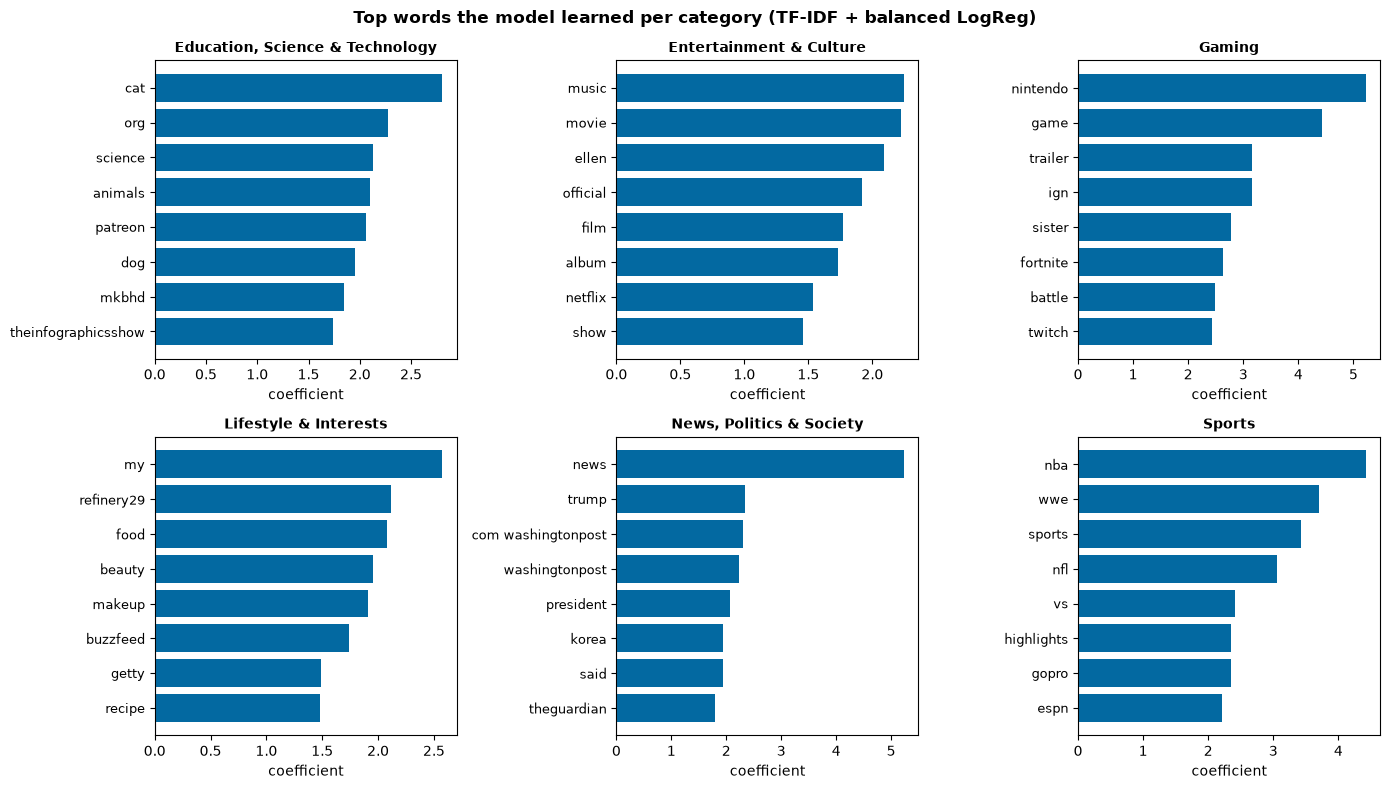

Top word per class:
  Education, Science & Technology     → 'cat' (2.80)
  Entertainment & Culture             → 'music' (2.25)
  Gaming                              → 'nintendo' (5.22)
  Lifestyle & Interests               → 'my' (2.57)
  News, Politics & Society            → 'news' (5.23)
  Sports                              → 'nba' (4.42)


In [85]:
# KEEP: coef_[class][word] = how much this word pulls toward that category
# Iris analog: high petal_width → setosa; here: high "nba" → Sports

import numpy as np

TOP_N = 8  # how many words to show per class
feature_names = vec_ng.get_feature_names_out()

n_classes = len(model_ng.classes_)
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=False)
axes = axes.flatten()

for ax, class_name, class_idx in zip(axes, model_ng.classes_, range(n_classes)):
    coefs = model_ng.coef_[class_idx]
    # argsort ascending → [-TOP_N:] takes the largest; [::-1] sorts largest to smallest
    top_idx = coefs.argsort()[-TOP_N:][::-1]
    words = feature_names[top_idx]
    weights = coefs[top_idx]

    # horizontal bars: y = word, x = coefficient
    y_pos = np.arange(len(words))
    ax.barh(y_pos, weights, color="#0369a1")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()  # strongest at the top
    ax.set_title(class_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("coefficient")
    ax.axvline(0, color="#94a3b8", linewidth=0.8)

fig.suptitle(
    "Top words the model learned per category (TF-IDF + balanced LogReg)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# short table in the console (helps the mini-check)
print("Top word per class:")
for class_idx, class_name in enumerate(model_ng.classes_):
    i = model_ng.coef_[class_idx].argmax()
    print(f"  {class_name:35} → {feature_names[i]!r} ({model_ng.coef_[class_idx][i]:.2f})")


### Mini-check — words the model studied

Look at the chart (run the cell above) and answer in your own words:

1. Which word is the strongest pull for **Sports**? Does that match your intuition?
2. Which word is the strongest for **News, Politics & Society**?
3. Why might **Education, Science & Technology** show words like `cat` / `dog` / `animals` near the top? (hint: remember the Pets & Animals remap)
4. In one sentence: how is this chart the same idea as `petal_width` vs species in the iris notebook?

Optional TODO: change `TOP_N = 8` to `TOP_N = 15` and see if any surprising bigrams appear (e.g. two-word phrases).